<h3 style="color:#1E3A8A; font-family:Arial, Helvetica, sans-serif; margin-bottom:6px;">
  <b>IST 691 — Phase 2 (Part 2): Fine-Tuned Embedding Artifact (Transfer Learning)</b>
</h3>

<div style="font-family:Arial, Helvetica, sans-serif; line-height:1.55;">
  <p style="margin-top:0;">
    <b>Big picture.</b> This module runs Phase 2’s <span style="color:#B91C1C;"><b>deep-learning stage</b></span> by fine-tuning a pretrained SentenceTransformer on Phase 1 supervision signals, then generates a <b>fine-tuned embedding artifact</b> for the <b>same full dataset</b> used in Part 1. The exported artifact keeps the <b>exact same schema</b> as baseline so Part 3 can compare clustering outcomes under a symmetric policy.
  </p>

  <p>
    <b>Single source of truth (input).</b> One CSV dataset is loaded from the local working directory (or an explicit config path). Required fields for this module are:
    <ul style="margin-top:4px;">
      <li><b>belief_sentence</b> (sentence text to embed)</li>
      <li><b>year_quarter</b> (timeline key for Phase 3 readiness)</li>
      <li><b>sentence_id</b> (preferred) or a stable id constructed when absent</li>
      <li><b>Soft-label fields</b> (used only to derive <code>label_key</code> for training pairs; not used for clustering decisions)</li>
    </ul>
  </p>

  <p>
    <b>Core logic flow.</b>
    <ol style="margin-top:4px;">
      <li><b>Load + validate</b> schema and stabilize <code>sentence_id</code> (row order preserved).</li>
      <li><b>Derive supervision</b> by forming <code>label_key</code> and selecting label_keys with enough samples to form pairs.</li>
      <li><b>Fine-tune or reuse checkpoint</b> via model-stamp validation (train only when reuse is not validated).</li>
      <li><b>Embed the full dataset</b> using the fine-tuned checkpoint (same rows as baseline).</li>
      <li><b>Export standardized artifacts</b> (embeddings + manifests + training report) for Part 3 comparison and Phase 3 timeline aggregation.</li>
    </ol>
  </p>

  <p>
    <b>Deep learning (what happens in this step).</b> Fine-tuning is <b>transfer learning</b>: pretrained encoder parameters are updated so sentences sharing the same <code>label_key</code> move closer in embedding space under a contrastive objective.
    In this run, the model reported <b>full-model fine-tuning</b> (<b>trainable_params = total_params = 22,713,216</b>).
  </p>

  <p>
    <b>Deep learning configuration (focused, observed in the run).</b>
    <ul style="margin-top:4px;">
      <li><b>Base checkpoint:</b> <code>sentence-transformers/all-MiniLM-L6-v2</code> (pretrained initialization)</li>
      <li><b>Objective:</b> <code>inbatch_contrastive_cross_entropy</code> (paired positives; in-batch negatives)</li>
      <li><b>Key hyperparameters:</b> <b>epochs = 1</b>, <b>batch_size = 32</b>, <b>learning_rate = 2e-05</b> <span style="color:#6B7280;">(small-step adaptation)</span></li>
      <li><b>Stability controls:</b> <b>grad_clip_norm = 1.0</b>, <b>max_seq_length_effective = 256</b></li>
      <li><b>Compute device:</b> <b>mps</b> (Apple Silicon acceleration)</li>
    </ul>
  </p>

  <p>
    <b>Model context (architecture identifiers observed in the run).</b>
    <ul style="margin-top:4px;">
      <li><b>Encoder type:</b> <b>bert</b> <span style="color:#6B7280;">(MiniLM-family encoder)</span></li>
      <li><b>Embedding dimension:</b> <b>384</b></li>
      <li><b>Pooling strategy:</b> mean pooling enabled (<code>pooling_mode_mean_tokens: true</code>)</li>
    </ul>
  </p>

  <p>
    <b>Training evidence (compact, observed in the run).</b>
    <ul style="margin-top:4px;">
      <li><b>Training pairs:</b> <b>2353</b> (from <b>106</b> unique label_keys in train)</li>
      <li><b>Training steps:</b> <b>73</b> (batches_per_epoch = 73)</li>
      <li><b>Runtime (fine-tuning stage):</b> <b>14.656 seconds</b></li>
      <li><b>Loss trend:</b> <b>4.380142 → 3.376745</b> <span style="color:#6B7280;">(first to last step)</span></li>
      <li><b>Checkpoint:</b> <span style="color:#B91C1C;"><b>trained in this run</b></span> (<b>checkpoint_reused = False</b>), saved under <code>.../IST691_phase2_output/models/part2_finetuned_minilm__2c987a2f7783</code></li>
    </ul>
  </p>

  <p>
    <b>Deliverables (local exports).</b> All outputs are saved under <code>IST691_phase2_output/part2_finetuned/</code>:
    <ul style="margin-top:4px;">
      <li><b>part2_finetuned_embeddings.parquet</b> (or csv): <code>sentence_id, year_quarter, belief_sentence, embedding</code></li>
      <li><b>part2_finetuned_summary.csv</b>: row counts, embedding dimension, missing-text count, runtime, norm stats</li>
      <li><b>part2_finetuned_embedding_manifest.json</b>: input checksum, schema, parameters, output file list</li>
      <li><b>Training report</b> (csv): steps, runtime, loss/lr summary, checkpoint metadata (audit-ready)</li>
      <li><b>Model manifest</b> (json): model stamp + validation metadata for checkpoint reuse control</li>
      <li><b>Preview csv</b> (top rows) for quick inspection without loading the full artifact</li>
    </ul>
  </p>

  <p style="margin-bottom:0;">
    <b>Console exhibit.</b> The run prints a compact header, supervised subset + pair counts, a focused deep-learning configuration summary, a training report preview, and a small embeddings preview table with stable file paths for retrieval.
  </p>
</div>

<hr style="border:none; border-top:1px solid #ddd; margin:12px 0;">



>>> ist 691 — phase 2 (part 2): deep learning fine-tuning + fine-tuned embedding

------------------------------------------------------------------------------------------------------------------------
[ walkthrough (logic flow + data flow) ]
------------------------------------------------------------------------------------------------------------------------
logic flow:
  1) resolve input csv and stabilize sentence_id (comparability key)
  2) enforce comparability gate using part 1 manifest when present
  3) construct supervision (label_key → positive pairs)
  4) transfer learning: fine-tune pretrained sentence-transformer checkpoint (optional reuse if validated)
  5) embed full dataset using fine-tuned checkpoint and export standardized embedding artifact
data flow:
  input csv → supervised subset → pairs → fine-tuned checkpoint → full-dataset embeddings artifact

[status]   6.25% (1/16) — resolve + load input csv

-----------------------------------------------------------------

/var/folders/x0/ktqmv5r113b9_vqrrx4z5zmc0000gp/T/ipykernel_11553/2114249442.py:605: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


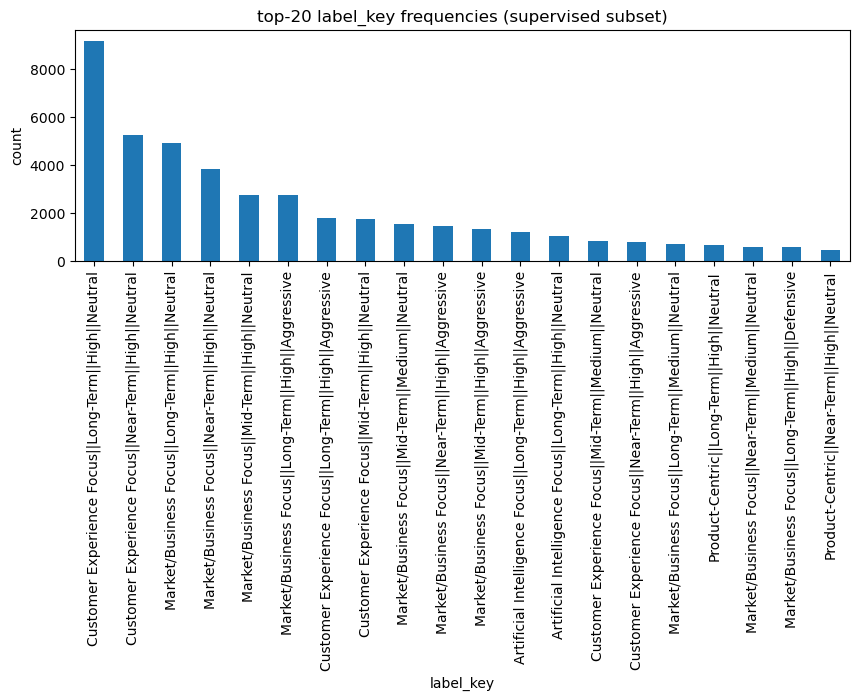


[status]  37.50% (6/16) — train/val/test split + export

------------------------------------------------------------------------------------------------------------------------
[ split summary ]
------------------------------------------------------------------------------------------------------------------------
shape: 1 x 3
 train_rows  val_rows  test_rows
39404       4925      4926      

[status]  43.75% (7/16) — positive pair construction + export

------------------------------------------------------------------------------------------------------------------------
[ pair construction summary ]
------------------------------------------------------------------------------------------------------------------------
shape: 1 x 5
 train_rows  unique_label_keys_train  pairs_built  pairs_per_label_cap  effective_batch_size
39404       106                      2353         50                   32                   

[status]  50.00% (8/16) — startup deep learning banner (transfer le

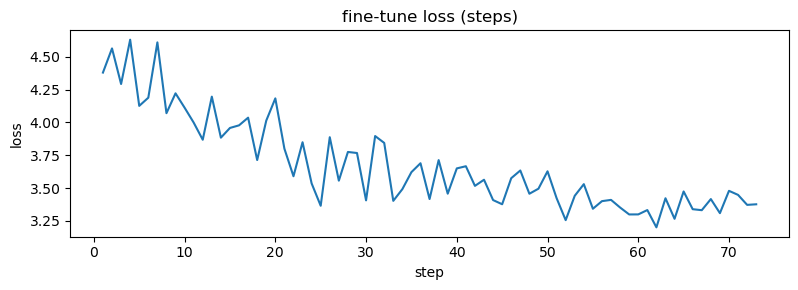

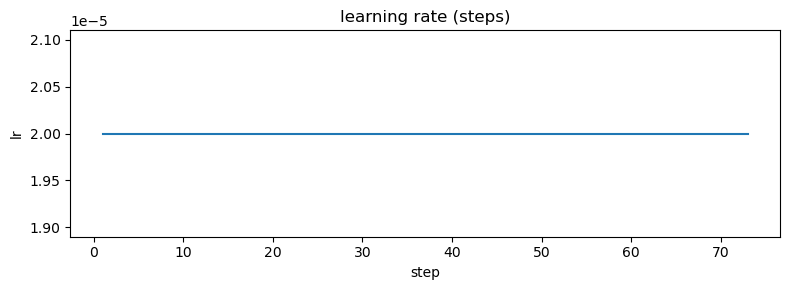


[status]  87.50% (14/16) — training summary (during/after training)

------------------------------------------------------------------------------------------------------------------------
[ training report (summary) ]
------------------------------------------------------------------------------------------------------------------------
shape: 1 x 28
pipeline_marker embedding_set transfer_learning                               base_checkpoint                        objective                          epochs  batch_size  learning_rate  weight_decay  warmup_ratio  grad_clip_norm  max_seq_length_effective  training_pairs  training_steps  batches_per_epoch  warmup_steps  runtime_seconds  loss_first  loss_last  loss_min  loss_mean  lr_first  lr_last evaluation_signal checkpoint_dir                                                                                                                                            checkpoint_reused device torch_version
IST691          finetuned     pr

Batches:   0%|          | 0/771 [00:00<?, ?it/s]


[status] 100.00% (17/16) — export embedding artifact + summary + manifest

[status] 100.00% (18/16) — final manifest (audit-ready, includes deep learning metadata)

[status] 100.00% (19/16) — console exhibit (focused, deep-learning visible)

------------------------------------------------------------------------------------------------------------------------
[ console exhibit ]
------------------------------------------------------------------------------------------------------------------------
outputs.embeddings        : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_outpu...
outputs.preview_csv       : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_outpu...
outputs.summary           : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_outpu...
outputs.manifest          : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-S

In [ ]:
"""
====================================================================================================
IST 691 — phase 2 (part 2)  |  fine-tuned embedding (transfer learning + contrastive training)
====================================================================================================

purpose
  - produce a fine-tuned sentence embedding artifact from the phase 1 refined sentence dataset
  - keep the embedding artifact schema identical to part 1 (baseline) for strict comparability in part 3

inputs (single source of truth)
  - input csv: phase 1 refined, sentence-level dataset
  - required columns: belief_sentence, year_quarter, stable id (sentence_id; constructed if missing)
  - optional columns: label fields (used only to construct supervision for fine-tuning)

processing (logic flow)
  1) load + validate input schema; enforce stable sentence_id; normalize text
  2) construct supervised subset:
       - build label_key from existing label fields (no new labels created)
       - split train/val/test for training integrity and reporting
       - build positive pairs within label_key groups (cap pairs per label to control dominance)
  3) deep learning stage (transfer learning):
       - base checkpoint: sentence-transformers/all-MiniLM-L6-v2
       - trainable parameters: transformer encoder + pooling module parameters (end-to-end fine-tuning)
       - objective: in-batch contrastive cross-entropy on cosine similarity (symmetric a→b and b→a)
       - checkpoint policy: reuse validated model if present; otherwise fine-tune and save checkpoint + manifest
  4) embed full dataset with the fine-tuned model (same rows, same order policy as baseline)
  5) export artifacts + audit manifests + console exhibits (preview tables; compact and readable)

outputs (local exports)
  - embeddings artifact (schema-aligned with baseline): sentence_id, year_quarter, belief_sentence, embedding
  - training report: loss + runtime + steps + checkpoint path (saved and previewed)
  - model manifest: architecture identifiers + hyperparameters + validation stamp (audit-ready)
  - run manifest: input checksum + row counts + output file list (traceable data-flow)

console exhibit (immediate review)
  - status tracker for major stages
  - split summary, pair summary, deep learning configuration banner, architecture report, training report preview
  - embedding artifact preview (top rows) and output path pointers

====================================================================================================

December 12 , 2025 | Syracuse University | IST 691 Deep Learning Term Project

Dujun; Yifeng; Isha 

"""

from __future__ import annotations

import json
import time
import random
import hashlib
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit

import torch
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader

from sentence_transformers import SentenceTransformer


# =============================================================================
# config (part 2 only)
# =============================================================================

@dataclass(frozen=True)
class Config:
    # input
    input_csv_path: Optional[str] = None  # absolute path optional; otherwise resolved locally
    expected_filename: str = "belief_extraction_results_deduped_year_quarter_flattened_repeat_deduped.csv"
    text_col: str = "belief_sentence"
    quarter_col: str = "year_quarter"
    preferred_id_cols: Tuple[str, ...] = ("sentence_id", "hash_id", "id")

    # labels for fine-tuning (supervision for deep learning stage)
    label_cols: Tuple[str, ...] = ("strategic_focus", "temporal_framing", "certainty_level", "market_position")
    min_label_count_for_training: int = 2
    max_pairs_per_label: int = 50

    # base model (transfer learning source checkpoint)
    base_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"

    # deep learning: optimization + training hyperparameters
    seed: int = 707
    epochs: int = 1
    batch_size: int = 32
    lr: float = 2e-5
    weight_decay: float = 0.0
    warmup_ratio: float = 0.0  # 0.0 disables warmup
    similarity_scale: float = 20.0
    grad_clip_norm: float = 1.0  # 0 disables clipping
    max_seq_length: Optional[int] = None  # None keeps model default

    # embedding
    embed_batch_size: int = 64

    # output
    output_root: str = str(Path.cwd().resolve() / "IST691_phase2_output")
    save_format: str = "parquet"  # parquet preferred; csv fallback supported
    console_width: int = 120
    preview_rows: int = 10


CFG = Config()


# =============================================================================
# console helpers (fixed width, left aligned)
# =============================================================================

def _header(title: str) -> None:
    bar = "=" * CFG.console_width
    print(f"\n{bar}\n>>> {title}\n{bar}")

def _section(title: str) -> None:
    bar = "-" * CFG.console_width
    print(f"\n{bar}\n[ {title} ]\n{bar}")

def _short(s: str, n: int = 96) -> str:
    s = str(s)
    return s if len(s) <= n else s[: n - 3] + "..."

def _print_kv(pairs: List[Tuple[str, str]], key_w: int = 26) -> None:
    for k, v in pairs:
        print(f"{k:<{key_w}}: {v}")

def _df_preview(df: pd.DataFrame, title: str, rows: Optional[int] = None) -> None:
    rows = CFG.preview_rows if rows is None else rows
    _section(title)
    pd.set_option("display.width", CFG.console_width)
    pd.set_option("display.max_colwidth", 70)
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.expand_frame_repr", False)
    head = df.head(rows).copy()
    if "belief_sentence" in head.columns:
        head["belief_sentence"] = head["belief_sentence"].astype(str).apply(lambda x: _short(x, 110))
    print(f"shape: {df.shape[0]} x {df.shape[1]}")
    print(head.to_string(index=False, justify="left"))

class Status:
    def __init__(self, total_steps: int):
        self.total = total_steps
        self.done = 0

    def step(self, msg: str) -> None:
        self.done += 1
        pct = min(100.0, 100.0 * self.done / max(1, self.total))
        print(f"\n[status] {pct:6.2f}% ({self.done}/{self.total}) — {msg}")


# =============================================================================
# io + comparability
# =============================================================================

def _md5_file(path: Path, chunk: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with path.open("rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def _resolve_input_csv() -> Path:
    cwd = Path.cwd().resolve()

    if CFG.input_csv_path:
        p = Path(CFG.input_csv_path).expanduser().resolve()
        if not p.exists():
            raise FileNotFoundError(f"input csv not found: {p}")
        return p

    expected = cwd / CFG.expected_filename
    if expected.exists():
        return expected

    candidates = sorted(cwd.glob("belief_extraction*.csv"))
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        candidates = sorted(candidates, key=lambda x: x.stat().st_size, reverse=True)
        return candidates[0]

    candidates = sorted(cwd.glob("*.csv"))
    if len(candidates) == 1:
        return candidates[0]

    raise FileNotFoundError("input csv could not be resolved from local directory.")

def _pick_id_col(df: pd.DataFrame) -> Optional[str]:
    for c in CFG.preferred_id_cols:
        if c in df.columns:
            return c
    return None

def _build_stable_sentence_id(df: pd.DataFrame, text_col: str) -> pd.Series:
    norm = df[text_col].astype(str).str.strip()
    ids = norm.apply(lambda s: hashlib.md5(s.encode("utf-8")).hexdigest()[:16])
    if ids.duplicated().any():
        ids = ids + "_" + df.index.astype(str)
    return ids

def _sentence_id_list_hash(sentence_ids: List[str]) -> str:
    return hashlib.md5(("|".join(sentence_ids)).encode("utf-8")).hexdigest()

def _load_part1_manifest_if_exists(output_root: Path) -> Optional[dict]:
    p = output_root / "part1_baseline" / "part1_baseline_embedding_manifest.json"
    if p.exists():
        with p.open("r", encoding="utf-8") as f:
            return json.load(f)
    return None

def _comparability_gate(part1_manifest: Optional[dict], input_md5: str, sid_hash: str) -> None:
    if not part1_manifest:
        return
    m_in = part1_manifest.get("input", {})
    md5_ok = (m_in.get("input_md5") == input_md5)
    sid_ok = (m_in.get("sentence_id_list_hash") == sid_hash)
    if not (md5_ok and sid_ok):
        raise RuntimeError(
            "comparability gate failed (part 1 vs part 2 mismatch)\n"
            f"part1.input_md5={m_in.get('input_md5')}\n"
            f"part2.input_md5={input_md5}\n"
            f"part1.sentence_id_list_hash={m_in.get('sentence_id_list_hash')}\n"
            f"part2.sentence_id_list_hash={sid_hash}\n"
        )


# =============================================================================
# fine-tuning data utilities (supervision construction)
# =============================================================================

def _validate_label_cols(df: pd.DataFrame) -> None:
    missing = [c for c in CFG.label_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"missing label columns required for fine-tuning: {missing}\n"
            f"available columns: {list(df.columns)}"
        )

def _make_label_key(df: pd.DataFrame) -> pd.Series:
    cols = list(CFG.label_cols)
    tmp = df[cols].copy()

    for c in cols:
        s = tmp[c].astype("string").str.strip()
        s_lower = s.str.lower()
        missing_mask = s.isna() | s_lower.isin(["", "nan", "none", "<na>"])
        s = s.mask(missing_mask, pd.NA)
        tmp[c] = s

    bad = tmp.isna().any(axis=1)
    filled = tmp.fillna("")
    key = filled.astype(str).agg("||".join, axis=1).astype("string")
    key = key.mask(bad, pd.NA)
    return key

def _stratified_split(df_sup: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    y = df_sup["label_key"].values
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=CFG.seed)
    train_idx, temp_idx = next(sss1.split(df_sup, y))
    df_train = df_sup.iloc[train_idx].reset_index(drop=True)
    df_temp = df_sup.iloc[temp_idx].reset_index(drop=True)

    counts_temp = df_temp["label_key"].value_counts()
    min_count = int(counts_temp.min()) if len(counts_temp) else 0

    if min_count < 2:
        ss = ShuffleSplit(n_splits=1, test_size=0.5, random_state=CFG.seed)
        val_idx, test_idx = next(ss.split(df_temp))
    else:
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=CFG.seed)
        val_idx, test_idx = next(sss2.split(df_temp, df_temp["label_key"].values))

    df_val = df_temp.iloc[val_idx].reset_index(drop=True)
    df_test = df_temp.iloc[test_idx].reset_index(drop=True)
    return df_train, df_val, df_test

def _make_positive_pairs(df_train: pd.DataFrame) -> pd.DataFrame:
    rng = np.random.default_rng(CFG.seed)
    rows = []
    for lk, sub in df_train.groupby("label_key"):
        idxs = sub.index.to_numpy()
        if len(idxs) < 2:
            continue
        rng.shuffle(idxs)
        n_pairs = min(CFG.max_pairs_per_label, len(idxs) // 2)
        for i in range(n_pairs):
            a = idxs[2 * i]
            b = idxs[2 * i + 1]
            rows.append({
                "label_key": lk,
                "sentence_a": df_train.loc[a, "belief_sentence"],
                "sentence_b": df_train.loc[b, "belief_sentence"],
            })
    return pd.DataFrame(rows)

class PairDataset(Dataset):
    def __init__(self, pairs_df: pd.DataFrame):
        self.a = pairs_df["sentence_a"].tolist()
        self.b = pairs_df["sentence_b"].tolist()

    def __len__(self) -> int:
        return len(self.a)

    def __getitem__(self, idx: int) -> Tuple[str, str]:
        return self.a[idx], self.b[idx]


# =============================================================================
# deep learning utilities (architecture + optimization reporting)
# =============================================================================

def _seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def _pick_device() -> str:
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def _count_parameters(model: torch.nn.Module) -> Dict[str, int]:
    total = sum(int(p.numel()) for p in model.parameters())
    trainable = sum(int(p.numel()) for p in model.parameters() if p.requires_grad)
    return {"total_params": total, "trainable_params": trainable}

def _safe_get(d: Any, path: List[str], default: Any = None) -> Any:
    cur = d
    for k in path:
        if cur is None:
            return default
        if isinstance(cur, dict):
            cur = cur.get(k, default)
        else:
            cur = getattr(cur, k, default)
    return cur

def _extract_architecture(model: SentenceTransformer) -> Dict[str, Any]:
    """
    Compact model identity for deep learning reporting.
    """
    arch: Dict[str, Any] = {}
    arch["sentence_embedding_dim"] = int(model.get_sentence_embedding_dimension())

    try:
        first = model._first_module()
        cfg = getattr(getattr(first, "auto_model", None), "config", None)
        arch["encoder_model_type"] = getattr(cfg, "model_type", None)
        arch["encoder_hidden_size"] = getattr(cfg, "hidden_size", None)
        arch["encoder_num_hidden_layers"] = getattr(cfg, "num_hidden_layers", None)
        arch["encoder_num_attention_heads"] = getattr(cfg, "num_attention_heads", None)
        arch["encoder_dropout_hidden"] = getattr(cfg, "hidden_dropout_prob", None)
        arch["encoder_dropout_attention"] = getattr(cfg, "attention_probs_dropout_prob", None)
    except Exception:
        arch["encoder_model_type"] = None

    pooling_info: Dict[str, Any] = {}
    try:
        for _, m in model._modules.items():
            if m.__class__.__name__ == "Pooling":
                pooling_info["pooling_mode_mean_tokens"] = bool(getattr(m, "pooling_mode_mean_tokens", False))
                pooling_info["pooling_mode_cls_token"] = bool(getattr(m, "pooling_mode_cls_token", False))
                pooling_info["pooling_mode_max_tokens"] = bool(getattr(m, "pooling_mode_max_tokens", False))
                pooling_info["pooling_mode_mean_sqrt_len_tokens"] = bool(getattr(m, "pooling_mode_mean_sqrt_len_tokens", False))
                pooling_info["pooling_mode_weightedmean_tokens"] = bool(getattr(m, "pooling_mode_weightedmean_tokens", False))
                break
    except Exception:
        pooling_info = {}

    arch["pooling"] = pooling_info
    arch["max_seq_length_effective"] = int(model.max_seq_length) if getattr(model, "max_seq_length", None) else None
    return arch

def _training_objective_description() -> Dict[str, str]:
    return {
        "name": "inbatch_contrastive_cross_entropy",
        "detail": (
            "for each batch of positive pairs (a_i, b_i), compute normalized embeddings, "
            "build similarity matrix S=a·b^T scaled by similarity_scale, "
            "optimize cross-entropy with diagonal as positives (symmetric a→b and b→a)."
        ),
        "supervision": "positive pairs derived from identical label_key over soft-label columns"
    }

def _make_lr_scheduler(optimizer: torch.optim.Optimizer, total_steps: int, warmup_steps: int):
    if warmup_steps <= 0:
        return None

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        denom = max(1, total_steps - warmup_steps)
        return max(0.0, float(total_steps - step) / float(denom))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

def _model_stamp(input_md5: str) -> str:
    stamp_payload = {
        "base_model_name": CFG.base_model_name,
        "seed": CFG.seed,
        "epochs": CFG.epochs,
        "batch_size": CFG.batch_size,
        "lr": CFG.lr,
        "weight_decay": CFG.weight_decay,
        "warmup_ratio": CFG.warmup_ratio,
        "similarity_scale": CFG.similarity_scale,
        "grad_clip_norm": CFG.grad_clip_norm,
        "max_seq_length": CFG.max_seq_length,
        "label_cols": list(CFG.label_cols),
        "min_label_count_for_training": CFG.min_label_count_for_training,
        "max_pairs_per_label": CFG.max_pairs_per_label,
        "input_md5": input_md5,
    }
    s = json.dumps(stamp_payload, sort_keys=True)
    return hashlib.md5(s.encode("utf-8")).hexdigest()[:12]

def _load_json(path: Path) -> Optional[dict]:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    return None

def _validate_existing_model(model_dir: Path, expected_stamp: str) -> bool:
    manifest = _load_json(model_dir / "part2_finetuned_model_manifest.json")
    if not manifest:
        return False
    return manifest.get("model_stamp") == expected_stamp

def _finetune_model(
    model: SentenceTransformer,
    pairs_df: pd.DataFrame,
    device: str,
) -> Tuple[SentenceTransformer, pd.DataFrame, pd.DataFrame, Dict[str, Any]]:
    """
    Deep learning stage (transfer learning):
      - parameters updated: all trainable parameters in the SentenceTransformer encoder stack
      - objective: symmetric in-batch contrastive cross-entropy
      - supervision: positive pairs created from label_key
    """
    ds = PairDataset(pairs_df)
    dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True)

    total_steps = len(dl) * CFG.epochs
    warmup_steps = int(round(CFG.warmup_ratio * total_steps))

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = _make_lr_scheduler(optimizer, total_steps=total_steps, warmup_steps=warmup_steps)

    model.to(device)
    model.train()

    loss_rows: List[Dict[str, Any]] = []
    step_rows: List[Dict[str, Any]] = []

    t_train0 = time.time()
    step = 0

    for epoch in range(CFG.epochs):
        for batch_a, batch_b in dl:
            step += 1

            feat_a = model.tokenize(list(batch_a))
            feat_b = model.tokenize(list(batch_b))
            feat_a = {k: v.to(device) for k, v in feat_a.items()}
            feat_b = {k: v.to(device) for k, v in feat_b.items()}

            emb_a = model(feat_a)["sentence_embedding"]
            emb_b = model(feat_b)["sentence_embedding"]
            emb_a = F.normalize(emb_a, p=2, dim=1)
            emb_b = F.normalize(emb_b, p=2, dim=1)

            logits = torch.matmul(emb_a, emb_b.T) * CFG.similarity_scale
            labels = torch.arange(logits.size(0), device=device)

            loss1 = F.cross_entropy(logits, labels)
            loss2 = F.cross_entropy(logits.T, labels)
            loss = 0.5 * (loss1 + loss2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()

            if CFG.grad_clip_norm and CFG.grad_clip_norm > 0:
                clip_grad_norm_(model.parameters(), max_norm=float(CFG.grad_clip_norm))

            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            lr_now = float(optimizer.param_groups[0]["lr"])

            loss_rows.append({
                "epoch": epoch + 1,
                "step": step,
                "total_steps": total_steps,
                "loss": float(loss.item()),
                "lr": lr_now,
            })
            step_rows.append({
                "epoch": epoch + 1,
                "step": step,
                "loss": float(loss.item()),
                "lr": lr_now,
            })

            if step == 1 or step == total_steps or (step % max(1, total_steps // 10) == 0):
                pct = 100.0 * step / max(1, total_steps)
                print(f"  [train] {pct:6.2f}% epoch={epoch+1}/{CFG.epochs} step={step}/{total_steps} loss={loss.item():.4f} lr={lr_now:.6g}")

    t_train1 = time.time()
    model.eval()

    loss_df = pd.DataFrame(loss_rows)
    steps_df = pd.DataFrame(step_rows)

    summary = {
        "training_steps": int(total_steps),
        "batches_per_epoch": int(len(dl)),
        "warmup_steps": int(warmup_steps),
        "runtime_seconds": float(round(t_train1 - t_train0, 3)),
        "loss_first": float(loss_df["loss"].iloc[0]) if len(loss_df) else None,
        "loss_last": float(loss_df["loss"].iloc[-1]) if len(loss_df) else None,
        "loss_min": float(loss_df["loss"].min()) if len(loss_df) else None,
        "loss_mean": float(loss_df["loss"].mean()) if len(loss_df) else None,
        "lr_first": float(loss_df["lr"].iloc[0]) if len(loss_df) else None,
        "lr_last": float(loss_df["lr"].iloc[-1]) if len(loss_df) else None,
        "early_stopping": "none",
        "evaluation_signal": "none",
    }

    return model, loss_df, steps_df, summary


# =============================================================================
# part 2
# =============================================================================

def part2_finetuned_embedding() -> None:
    _seed_everything(CFG.seed)

    status = Status(total_steps=16)
    t0 = time.time()
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    out_root = Path(CFG.output_root).resolve()
    out_dir = out_root / "part2_finetuned"
    data_dir = out_dir / "data"
    fig_dir = out_dir / "figures"
    reports_dir = out_dir / "reports"
    model_root = out_root / "models"
    manifests_dir = out_root / "manifests"

    for d in [out_dir, data_dir, fig_dir, reports_dir, model_root, manifests_dir]:
        d.mkdir(parents=True, exist_ok=True)

    _header("ist 691 — phase 2 (part 2): deep learning fine-tuning + fine-tuned embedding")
    _section("walkthrough (logic flow + data flow)")
    print("logic flow:")
    print("  1) resolve input csv and stabilize sentence_id (comparability key)")
    print("  2) enforce comparability gate using part 1 manifest when present")
    print("  3) construct supervision (label_key → positive pairs)")
    print("  4) transfer learning: fine-tune pretrained sentence-transformer checkpoint (optional reuse if validated)")
    print("  5) embed full dataset using fine-tuned checkpoint and export standardized embedding artifact")
    print("data flow:")
    print("  input csv → supervised subset → pairs → fine-tuned checkpoint → full-dataset embeddings artifact")

    status.step("resolve + load input csv")
    input_csv = _resolve_input_csv()
    input_md5 = _md5_file(input_csv)

    _section("inputs")
    _print_kv([
        ("timestamp", ts),
        ("cwd", str(Path.cwd().resolve())),
        ("input_csv", _short(str(input_csv), 110)),
        ("input_md5", input_md5),
        ("output_root", _short(str(out_root), 110)),
        ("part2_out_dir", _short(str(out_dir), 110)),
    ])

    df = pd.read_csv(input_csv)

    status.step("validate schema + stabilize ids")
    missing_req = [c for c in [CFG.text_col, CFG.quarter_col] if c not in df.columns]
    if missing_req:
        raise KeyError(f"missing required columns: {missing_req}")

    id_col = _pick_id_col(df)
    if id_col:
        df["sentence_id"] = df[id_col].astype(str)
    else:
        df["sentence_id"] = _build_stable_sentence_id(df, CFG.text_col)

    df["belief_sentence"] = df[CFG.text_col].astype(str).str.strip()
    df["year_quarter"] = df[CFG.quarter_col].astype(str).str.strip()

    missing_text_rows = int((df["belief_sentence"].str.len() == 0).sum())
    sid_hash = _sentence_id_list_hash(df["sentence_id"].tolist())

    _print_kv([
        ("rows x cols", f"{df.shape[0]} x {df.shape[1]}"),
        ("id source", id_col if id_col else "generated_from_text_md5"),
        ("missing_text_rows", str(missing_text_rows)),
        ("sentence_id_list_hash", sid_hash),
    ])

    status.step("comparability gate (part 1)")
    part1_manifest = _load_part1_manifest_if_exists(out_root)
    _comparability_gate(part1_manifest, input_md5, sid_hash)
    print("[info] comparability gate: ok (or part 1 manifest not present)")

    status.step("build supervised subset (label_key)")
    _validate_label_cols(df)
    df["label_key"] = _make_label_key(df)

    df_sup = df.dropna(subset=["label_key"]).copy()
    counts = df_sup["label_key"].value_counts()
    keep_keys = counts[counts >= CFG.min_label_count_for_training].index
    df_sup = df_sup[df_sup["label_key"].isin(keep_keys)].reset_index(drop=True)

    sup_summary = pd.DataFrame([{
        "rows_total": int(df.shape[0]),
        "rows_supervised": int(df_sup.shape[0]),
        "unique_label_keys": int(df_sup["label_key"].nunique()),
        "min_label_count_for_training": int(CFG.min_label_count_for_training),
        "max_pairs_per_label": int(CFG.max_pairs_per_label),
    }])
    _df_preview(sup_summary, "supervised subset summary", rows=1)

    status.step("export label_key frequency plot")
    topk = df_sup["label_key"].value_counts().head(20)
    plt.figure(figsize=(10, 3))
    topk.plot(kind="bar")
    plt.title("top-20 label_key frequencies (supervised subset)")
    plt.ylabel("count")
    plt.tight_layout()
    fig_label_key = fig_dir / "part2_label_key_top20.png"
    plt.savefig(fig_label_key, dpi=200)
    plt.show()

    status.step("train/val/test split + export")
    df_train, df_val, df_test = _stratified_split(df_sup)
    split_meta = pd.DataFrame([{
        "train_rows": int(len(df_train)),
        "val_rows": int(len(df_val)),
        "test_rows": int(len(df_test)),
    }])
    _df_preview(split_meta, "split summary", rows=1)

    train_path = data_dir / "part2_finetune_train_ready.csv"
    val_path = data_dir / "part2_finetune_val_ready.csv"
    test_path = data_dir / "part2_finetune_test_ready.csv"
    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    df_test.to_csv(test_path, index=False)

    status.step("positive pair construction + export")
    pairs_df = _make_positive_pairs(df_train)
    pairs_path = data_dir / "part2_finetune_positive_pairs.csv"
    pairs_df.to_csv(pairs_path, index=False)

    pair_summary = pd.DataFrame([{
        "train_rows": int(len(df_train)),
        "unique_label_keys_train": int(df_train["label_key"].nunique()),
        "pairs_built": int(len(pairs_df)),
        "pairs_per_label_cap": int(CFG.max_pairs_per_label),
        "effective_batch_size": int(CFG.batch_size),
    }])
    _df_preview(pair_summary, "pair construction summary", rows=1)

    if len(pairs_df) == 0:
        raise RuntimeError("no training pairs created (insufficient label_key density)")

    status.step("startup deep learning banner (transfer learning + hyperparameters)")
    device = _pick_device()
    expected_stamp = _model_stamp(input_md5)
    model_dir = model_root / f"part2_finetuned_minilm__{expected_stamp}"

    dl_objective = _training_objective_description()
    dl_config = pd.DataFrame([{
        "pipeline_marker": "IST691",
        "embedding_set": "finetuned",
        "stage": "deep_learning_finetuning",
        "transfer_learning_source": CFG.base_model_name,
        "objective_name": dl_objective["name"],
        "epochs": CFG.epochs,
        "batch_size": CFG.batch_size,
        "learning_rate": CFG.lr,
        "weight_decay": CFG.weight_decay,
        "warmup_ratio": CFG.warmup_ratio,
        "similarity_scale": CFG.similarity_scale,
        "grad_clip_norm": CFG.grad_clip_norm,
        "max_seq_length": CFG.max_seq_length if CFG.max_seq_length is not None else "model_default",
        "device": device,
        "model_stamp": expected_stamp,
    }])

    _df_preview(dl_config, "deep learning configuration (startup)", rows=1)
    dl_config_path = reports_dir / "part2_deep_learning_config.csv"
    dl_config.to_csv(dl_config_path, index=False)

    status.step("model reuse decision (validated)")
    model_ready = bool(model_dir.exists() and _validate_existing_model(model_dir, expected_stamp))

    _section("model checkpoint")
    _print_kv([
        ("model_stamp", expected_stamp),
        ("model_dir", _short(str(model_dir), 110)),
        ("device", device),
        ("reuse_validated", str(model_ready)),
    ])

    status.step("load model + apply max_seq_length policy")
    loss_df = pd.DataFrame(columns=["epoch", "step", "total_steps", "loss", "lr"])
    steps_df = pd.DataFrame(columns=["epoch", "step", "loss", "lr"])
    training_summary: Dict[str, Any] = {
        "training_steps": None,
        "batches_per_epoch": None,
        "warmup_steps": None,
        "runtime_seconds": None,
        "loss_first": None,
        "loss_last": None,
        "loss_min": None,
        "loss_mean": None,
        "lr_first": None,
        "lr_last": None,
        "early_stopping": "none",
        "evaluation_signal": "none",
        "used_checkpoint_reuse": bool(model_ready),
    }

    if model_ready:
        model = SentenceTransformer(str(model_dir), device=device)
        model_manifest_existing = _load_json(model_dir / "part2_finetuned_model_manifest.json") or {}
        training_summary.update(model_manifest_existing.get("training_summary", {}))
    else:
        model = SentenceTransformer(CFG.base_model_name, device=device)

    if CFG.max_seq_length is not None:
        model.max_seq_length = int(CFG.max_seq_length)

    status.step("architecture + parameter report (audit-ready)")
    params_before = _count_parameters(model)
    arch = _extract_architecture(model)

    arch_table = pd.DataFrame([{
        "pipeline_marker": "IST691",
        "base_model_name": CFG.base_model_name,
        "encoder_model_type": arch.get("encoder_model_type"),
        "encoder_hidden_size": arch.get("encoder_hidden_size"),
        "encoder_num_hidden_layers": arch.get("encoder_num_hidden_layers"),
        "encoder_num_attention_heads": arch.get("encoder_num_attention_heads"),
        "sentence_embedding_dim": arch.get("sentence_embedding_dim"),
        "pooling": json.dumps(arch.get("pooling", {}), sort_keys=True),
        "max_seq_length_effective": arch.get("max_seq_length_effective"),
        "dropout_hidden": arch.get("encoder_dropout_hidden"),
        "dropout_attention": arch.get("encoder_dropout_attention"),
        "total_params": params_before["total_params"],
        "trainable_params": params_before["trainable_params"],
    }])

    _df_preview(arch_table, "model architecture + parameters (pre-train)", rows=1)
    arch_path = reports_dir / "part2_model_architecture.csv"
    arch_table.to_csv(arch_path, index=False)

    status.step("fine-tune or reuse model (deep learning stage)")
    if not model_ready:
        model, loss_df, steps_df, training_summary = _finetune_model(model, pairs_df, device=device)

        model_dir.mkdir(parents=True, exist_ok=True)
        model.save(str(model_dir))

        status.step("save training report (loss + lr)")
        loss_csv = reports_dir / "part2_training_steps.csv"
        loss_df.to_csv(loss_csv, index=False)

        plt.figure(figsize=(8, 3))
        plt.plot(loss_df["step"], loss_df["loss"])
        plt.title("fine-tune loss (steps)")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.tight_layout()
        fig_loss = fig_dir / "part2_training_loss_curve.png"
        plt.savefig(fig_loss, dpi=200)
        plt.show()

        plt.figure(figsize=(8, 3))
        plt.plot(loss_df["step"], loss_df["lr"])
        plt.title("learning rate (steps)")
        plt.xlabel("step")
        plt.ylabel("lr")
        plt.tight_layout()
        fig_lr = fig_dir / "part2_training_lr_curve.png"
        plt.savefig(fig_lr, dpi=200)
        plt.show()
    else:
        loss_csv = None
        fig_loss = None
        fig_lr = None

    status.step("training summary (during/after training)")
    training_report = pd.DataFrame([{
        "pipeline_marker": "IST691",
        "embedding_set": "finetuned",
        "transfer_learning": "pretrained_sentence_transformer_to_domain_pairs",
        "base_checkpoint": CFG.base_model_name,
        "objective": dl_objective["name"],
        "epochs": CFG.epochs,
        "batch_size": CFG.batch_size,
        "learning_rate": CFG.lr,
        "weight_decay": CFG.weight_decay,
        "warmup_ratio": CFG.warmup_ratio,
        "grad_clip_norm": CFG.grad_clip_norm,
        "max_seq_length_effective": arch.get("max_seq_length_effective"),
        "training_pairs": int(len(pairs_df)),
        "training_steps": training_summary.get("training_steps"),
        "batches_per_epoch": training_summary.get("batches_per_epoch"),
        "warmup_steps": training_summary.get("warmup_steps"),
        "runtime_seconds": training_summary.get("runtime_seconds"),
        "loss_first": training_summary.get("loss_first"),
        "loss_last": training_summary.get("loss_last"),
        "loss_min": training_summary.get("loss_min"),
        "loss_mean": training_summary.get("loss_mean"),
        "lr_first": training_summary.get("lr_first"),
        "lr_last": training_summary.get("lr_last"),
        "evaluation_signal": training_summary.get("evaluation_signal"),
        "checkpoint_dir": str(model_dir),
        "checkpoint_reused": bool(training_summary.get("used_checkpoint_reuse", model_ready)),
        "device": device,
        "torch_version": torch.__version__,
    }])
    _df_preview(training_report, "training report (summary)", rows=1)

    training_report_path = reports_dir / "part2_training_report.csv"
    training_report.to_csv(training_report_path, index=False)

    status.step("write model manifest (validation stamp + deep learning metadata)")
    params_after = _count_parameters(model)
    deep_learning_manifest = {
        "pipeline_marker": "IST691",
        "part": "part2_finetuned_model",
        "embedding_set": "finetuned",
        "model_stamp": expected_stamp,
        "run_timestamp": datetime.now().isoformat(timespec="seconds"),
        "input_md5": input_md5,
        "device_used": device,
        "torch_version": torch.__version__,
        "transfer_learning": {
            "source_checkpoint": CFG.base_model_name,
            "target_task": "domain sentence similarity via label_key positive pairs",
        },
        "objective": _training_objective_description(),
        "hyperparameters": {
            "seed": CFG.seed,
            "epochs": CFG.epochs,
            "batch_size": CFG.batch_size,
            "lr": CFG.lr,
            "weight_decay": CFG.weight_decay,
            "warmup_ratio": CFG.warmup_ratio,
            "similarity_scale": CFG.similarity_scale,
            "grad_clip_norm": CFG.grad_clip_norm,
            "max_seq_length": CFG.max_seq_length,
        },
        "architecture": arch,
        "parameters": {
            "before": params_before,
            "after": params_after,
            "trainable_parameter_policy": "all_trainable_parameters_updated",
        },
        "supervision": {
            "label_cols": list(CFG.label_cols),
            "label_key_definition": "row signature over label_cols joined with '||' (rows with any missing label excluded)",
            "min_label_count_for_training": int(CFG.min_label_count_for_training),
            "max_pairs_per_label": int(CFG.max_pairs_per_label),
            "supervised_rows": int(df_sup.shape[0]),
            "training_pairs": int(len(pairs_df)),
        },
        "training_summary": training_summary,
        "checkpoint_dir": str(model_dir),
    }

    model_manifest_path = model_dir / "part2_finetuned_model_manifest.json"
    with model_manifest_path.open("w", encoding="utf-8") as f:
        json.dump(deep_learning_manifest, f, indent=2)
    with (manifests_dir / f"part2_finetuned_model_manifest__{expected_stamp}.json").open("w", encoding="utf-8") as f:
        json.dump(deep_learning_manifest, f, indent=2)

    status.step("embed full dataset (fine-tuned)")
    emb = model.encode(
        df["belief_sentence"].tolist(),
        batch_size=CFG.embed_batch_size,
        show_progress_bar=True,
        device=device,
    )
    emb = np.asarray(emb, dtype="float32")
    emb_dim = int(emb.shape[1])

    norms = np.linalg.norm(emb, axis=1)
    norm_min, norm_mean, norm_max = float(norms.min()), float(norms.mean()), float(norms.max())

    status.step("export embedding artifact + summary + manifest")
    emb_df = df[["sentence_id", "year_quarter", "belief_sentence"]].copy()
    emb_df["embedding"] = emb.tolist()

    emb_path = out_dir / "part2_finetuned_embeddings.parquet"
    if str(CFG.save_format).lower() == "parquet":
        emb_df.to_parquet(emb_path, index=False)
    else:
        emb_path = emb_path.with_suffix(".csv")
        emb_df.to_csv(emb_path, index=False)

    preview_path = out_dir / "part2_finetuned_embeddings_preview.csv"
    preview_df = emb_df.head(CFG.preview_rows).copy()
    preview_df["embedding"] = preview_df["embedding"].apply(lambda v: f"len={len(v)}")
    preview_df.to_csv(preview_path, index=False)

    elapsed = time.time() - t0
    summary = pd.DataFrame([{
        "embedding_set": "finetuned",
        "input_csv_name": Path(input_csv).name,
        "input_md5": input_md5,
        "input_rows": int(df.shape[0]),
        "missing_text_rows": int(missing_text_rows),
        "embedding_dim": emb_dim,
        "supervised_rows": int(df_sup.shape[0]),
        "pairs_built": int(len(pairs_df)),
        "model_stamp": expected_stamp,
        "device": device,
        "elapsed_seconds": round(elapsed, 3),
        "embedding_norm_min": round(norm_min, 6),
        "embedding_norm_mean": round(norm_mean, 6),
        "embedding_norm_max": round(norm_max, 6),
        "sentence_id_list_hash": sid_hash,
    }])
    summary_path = out_dir / "part2_finetuned_summary.csv"
    summary.to_csv(summary_path, index=False)

    status.step("final manifest (audit-ready, includes deep learning metadata)")
    embedding_manifest = {
        "pipeline_marker": "IST691",
        "part": "part2_finetuned",
        "embedding_set": "finetuned",
        "run_timestamp": datetime.now().isoformat(timespec="seconds"),
        "input": {
            "input_csv_path": str(input_csv),
            "input_md5": input_md5,
            "input_row_count": int(df.shape[0]),
            "required_columns": [CFG.text_col, CFG.quarter_col],
            "sentence_id_source": id_col if id_col else "generated_from_text_md5",
            "sentence_id_list_hash": sid_hash,
        },
        "deep_learning": {
            "transfer_learning": deep_learning_manifest.get("transfer_learning"),
            "objective": deep_learning_manifest.get("objective"),
            "hyperparameters": deep_learning_manifest.get("hyperparameters"),
            "architecture": deep_learning_manifest.get("architecture"),
            "parameters": deep_learning_manifest.get("parameters"),
            "training_summary": deep_learning_manifest.get("training_summary"),
            "checkpoint_dir": str(model_dir),
            "checkpoint_reused": bool(training_summary.get("used_checkpoint_reuse", model_ready)),
        },
        "embedding": {
            "embedding_dim": emb_dim,
            "device": device,
            "embed_batch_size": CFG.embed_batch_size,
            "embedding_norm_min": norm_min,
            "embedding_norm_mean": norm_mean,
            "embedding_norm_max": norm_max,
        },
        "outputs": [
            {"name": "finetuned_embeddings", "relpath": str(emb_path.relative_to(out_root))},
            {"name": "finetuned_embeddings_preview", "relpath": str(preview_path.relative_to(out_root))},
            {"name": "finetuned_summary", "relpath": str(summary_path.relative_to(out_root))},
            {"name": "deep_learning_config_csv", "relpath": str(dl_config_path.relative_to(out_root))},
            {"name": "model_architecture_csv", "relpath": str(arch_path.relative_to(out_root))},
            {"name": "training_report_csv", "relpath": str(training_report_path.relative_to(out_root))},
            {"name": "train_csv", "relpath": str(train_path.relative_to(out_root))},
            {"name": "val_csv", "relpath": str(val_path.relative_to(out_root))},
            {"name": "test_csv", "relpath": str(test_path.relative_to(out_root))},
            {"name": "pairs_csv", "relpath": str(pairs_path.relative_to(out_root))},
            {"name": "label_key_plot", "relpath": str(fig_label_key.relative_to(out_root))},
        ],
    }

    if loss_csv is not None:
        embedding_manifest["outputs"].append({"name": "training_steps_csv", "relpath": str(Path(loss_csv).relative_to(out_root))})
    if fig_loss is not None:
        embedding_manifest["outputs"].append({"name": "training_loss_plot", "relpath": str(Path(fig_loss).relative_to(out_root))})
    if fig_lr is not None:
        embedding_manifest["outputs"].append({"name": "training_lr_plot", "relpath": str(Path(fig_lr).relative_to(out_root))})

    manifest_path = out_dir / "part2_finetuned_embedding_manifest.json"
    with manifest_path.open("w", encoding="utf-8") as f:
        json.dump(embedding_manifest, f, indent=2)
    with (manifests_dir / manifest_path.name).open("w", encoding="utf-8") as f:
        json.dump(embedding_manifest, f, indent=2)

    status.step("console exhibit (focused, deep-learning visible)")
    _section("console exhibit")
    _print_kv([
        ("outputs.embeddings", _short(str(emb_path), 110)),
        ("outputs.preview_csv", _short(str(preview_path), 110)),
        ("outputs.summary", _short(str(summary_path), 110)),
        ("outputs.manifest", _short(str(manifest_path), 110)),
        ("outputs.model_dir", _short(str(model_dir), 110)),
        ("outputs.reports_dir", _short(str(reports_dir), 110)),
        ("outputs.fig_dir", _short(str(fig_dir), 110)),
        ("outputs.data_dir", _short(str(data_dir), 110)),
    ])

    _df_preview(summary, "summary preview", rows=1)
    _df_preview(training_report, "training report preview", rows=1)
    _df_preview(preview_df, "embeddings preview (top rows)", rows=CFG.preview_rows)

    status.step("done")
    _header("part 2 completed")


# run
part2_finetuned_embedding()
